In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import cv2
import os

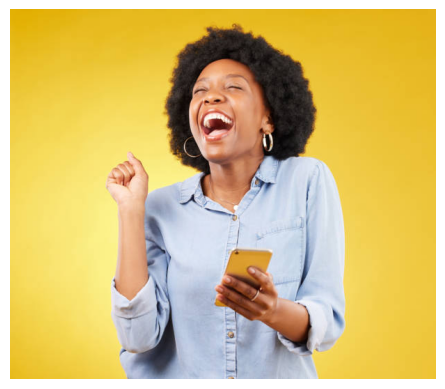

In [8]:
img = image.load_img('./training-1/happy/1.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

In [9]:
i1=cv2.imread('./training-1/happy/1.jpg')
i1

array([[[  4, 177, 227],
        [  4, 177, 227],
        [  4, 177, 227],
        ...,
        [ 25, 178, 229],
        [ 25, 178, 229],
        [ 25, 178, 229]],

       [[  4, 177, 227],
        [  4, 177, 227],
        [  4, 177, 227],
        ...,
        [ 25, 178, 229],
        [ 25, 178, 229],
        [ 25, 178, 229]],

       [[  4, 177, 227],
        [  4, 177, 227],
        [  4, 177, 227],
        ...,
        [ 25, 178, 229],
        [ 25, 178, 229],
        [ 25, 178, 229]],

       ...,

       [[ 27, 186, 230],
        [ 27, 186, 230],
        [ 27, 186, 230],
        ...,
        [ 49, 195, 237],
        [ 49, 195, 237],
        [ 49, 195, 237]],

       [[ 27, 186, 230],
        [ 27, 186, 230],
        [ 27, 186, 230],
        ...,
        [ 49, 195, 237],
        [ 49, 195, 237],
        [ 49, 195, 237]],

       [[ 27, 186, 230],
        [ 27, 186, 230],
        [ 27, 186, 230],
        ...,
        [ 49, 195, 237],
        [ 49, 195, 237],
        [ 49, 195, 237]]

In [11]:
i1.shape

(531, 612, 3)

In [13]:
train = ImageDataGenerator(rescale=1/200)
validation = ImageDataGenerator(rescale=1/200)

In [21]:
train_dataset = train.flow_from_directory(
    directory='./training-1',
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)
validation_dataset = validation.flow_from_directory(
    directory='./validation',
    target_size=(200, 200),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)



Found 10 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [22]:
train_dataset.class_indices

{'happy': 0, 'sad': 1}

In [23]:
train_dataset.classes

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

In [25]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


In [26]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [ ]:
model_fit = model.fit(
    train_dataset,
    epochs=10,
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5000 - loss: 11.4892
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5000 - loss: 6.1913
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5000 - loss: 0.6120
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 1.0000 - loss: 0.5073
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5000 - loss: 0.9720
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.5000 - loss: 0.7195
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.6000 - loss: 0.4727
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9000 - loss: 0.3721
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9000 - loss: 0.2243
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.5000 - loss: 3.0687


In [ ]:
# model.compile(optimizer='adam',
#               loss='binary_crossentropy',
#               metrics=['accuracy'])
# model.summary()

In [31]:
dir_path = './testing'
for i in os.listdir(dir_path):
    print(i)

8.jpg
9.jpg
10.jpg
4.jpg
5.jpg
7.jpg
6.jpg
2.jpg
3.jpg
1.jpg


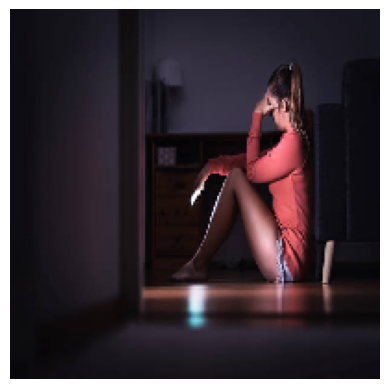

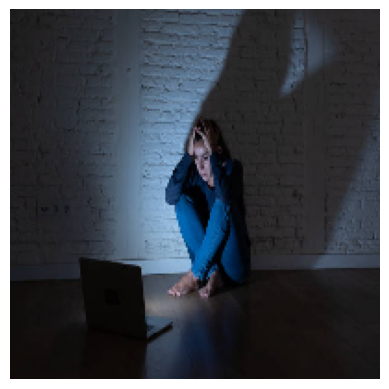

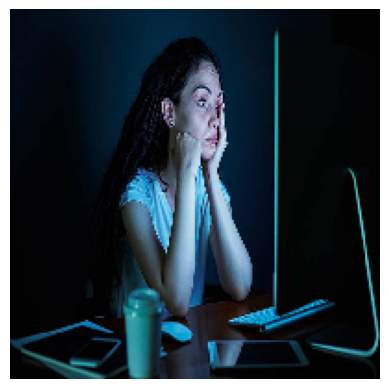

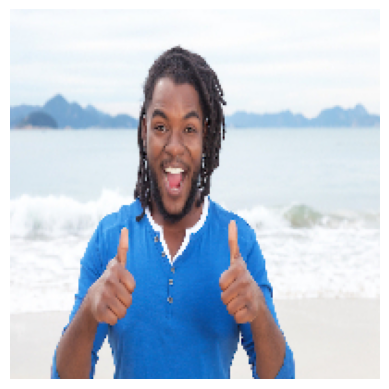

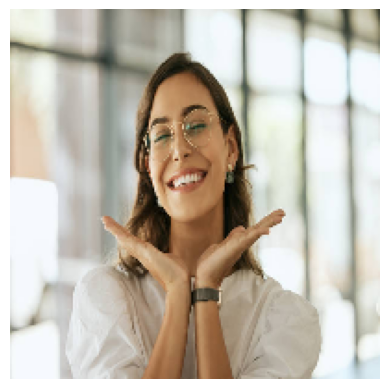

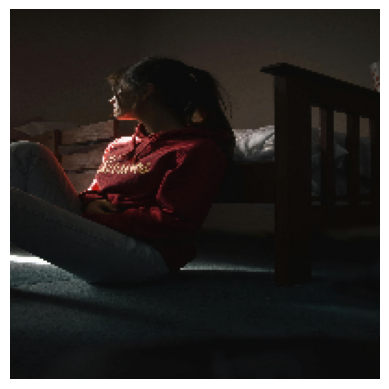

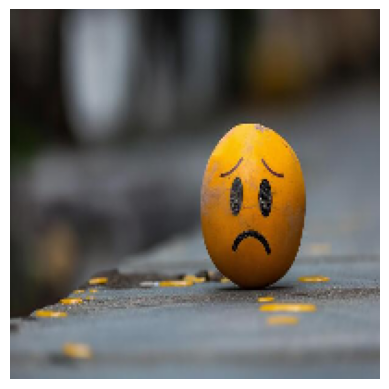

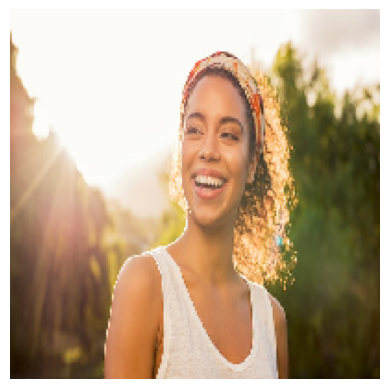

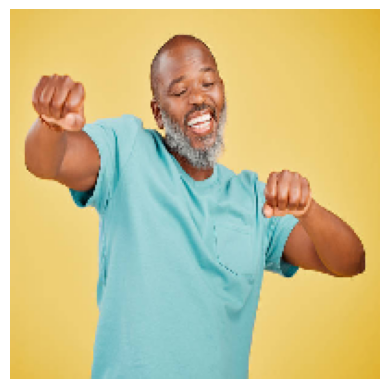

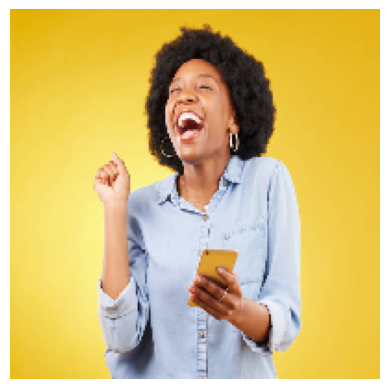

In [32]:
dir_path = './testing'
for i in os.listdir(dir_path):
    img = image.load_img(os.path.join(dir_path, i), target_size=(200, 200))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
   

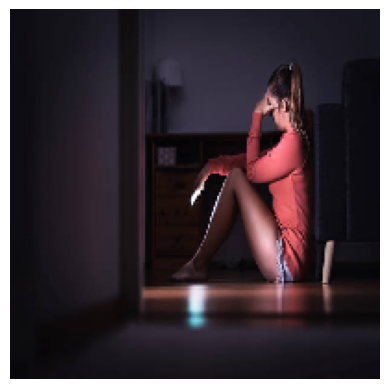

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
8.jpg is happy


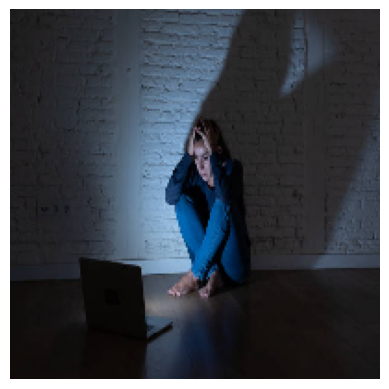

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
9.jpg is happy


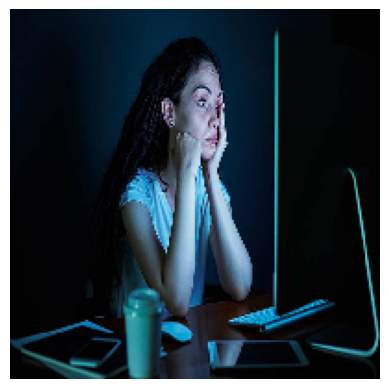

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
10.jpg is happy


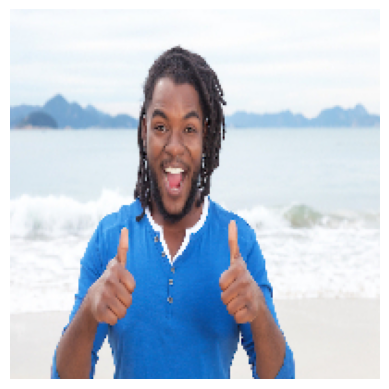

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4.jpg is happy


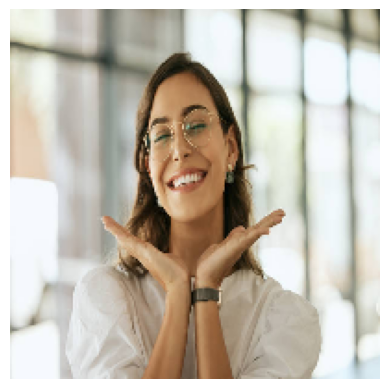

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
5.jpg is happy


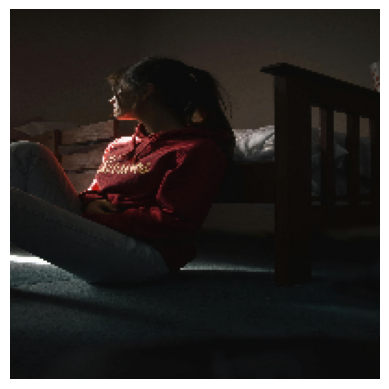

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
7.jpg is happy


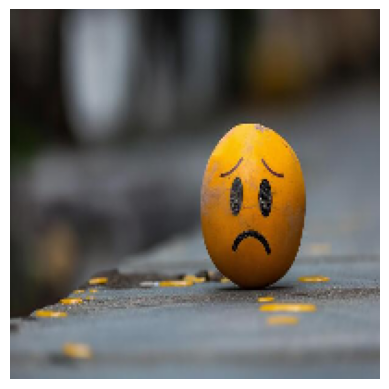

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6.jpg is happy


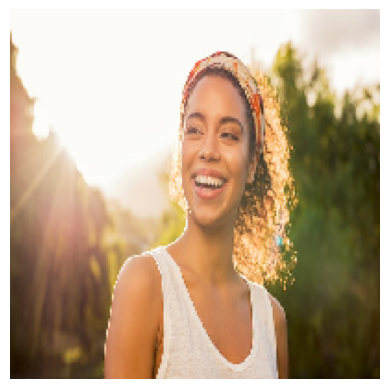

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2.jpg is happy


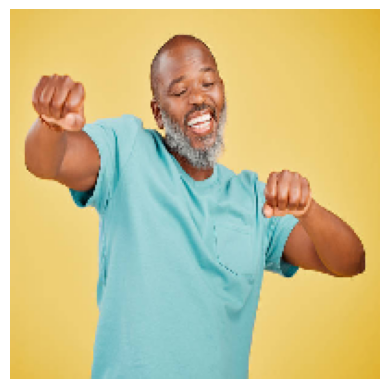

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
3.jpg is happy


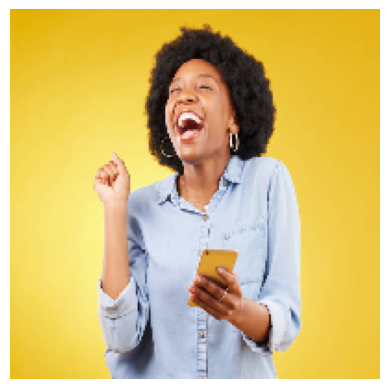

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1.jpg is happy


In [35]:
dir_path = './testing'
for i in os.listdir(dir_path):
    img = image.load_img(os.path.join(dir_path, i), target_size=(200, 200))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    images = np.vstack([x])
    val = model.predict(images)
    if val == 0:
        print(f"{i} is happy")
    else:
        print(f"{i} is sad")
    # classes = model.predict(images, batch_size=10)
    # print(f"Prediction for {i}: {'Happy' if classes[0][0] > 0.5 else 'Sad'}")